In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print("Libraries imported successfully!")


2026-01-26 03:52:51.498130: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769399571.703872      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769399571.762322      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769399572.257046      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769399572.257105      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769399572.257108      55 computation_placer.cc:177] computation placer alr

Libraries imported successfully!


In [2]:
import os

if os.path.exists('/kaggle/input'):
    possible_datasets = ['hcdataset', 'hc-headcircumference', 'fetal-head-circumference']
    DATA_PATH = None
    
    for dataset_name in possible_datasets:
        test_path = f'/kaggle/input/{dataset_name}'
        if os.path.exists(test_path):
            DATA_PATH = test_path
            print(f"Running on Kaggle - Found dataset: {dataset_name}")
            break
    
    if DATA_PATH is None:
        print("Available datasets in /kaggle/input:")
        if os.path.exists('/kaggle/input'):
            print(os.listdir('/kaggle/input'))
        DATA_PATH = '/kaggle/input'
        print(f"Using default path: {DATA_PATH}")
    
    OUTPUT_PATH = '/kaggle/working'
else:
    DATA_PATH = '.'
    OUTPUT_PATH = '.'
    print("Running locally")


Running on Kaggle - Found dataset: hcdataset


In [3]:
print(f"Contents of {DATA_PATH}:")
if os.path.exists(DATA_PATH):
    print(os.listdir(DATA_PATH))
else:
    print(f"Path {DATA_PATH} does not exist")

if not os.path.exists(f'{DATA_PATH}/training_set'):
    if os.path.exists(f'{DATA_PATH}/training_set.zip'):
        with zipfile.ZipFile(f'{DATA_PATH}/training_set.zip', 'r') as zip_ref:
            zip_ref.extractall(DATA_PATH)
        print("Training set extracted")
    else:
        print("Training set already extracted or zip file not found")
else:
    print("Training set directory already exists")

if not os.path.exists(f'{DATA_PATH}/test_set'):
    if os.path.exists(f'{DATA_PATH}/test_set.zip'):
        with zipfile.ZipFile(f'{DATA_PATH}/test_set.zip', 'r') as zip_ref:
            zip_ref.extractall(DATA_PATH)
        print("Test set extracted")
    else:
        print("Test set already extracted or zip file not found")
else:
    print("Test set directory already exists")


Contents of /kaggle/input/hcdataset:
['test_set', 'training_set_pixel_size_and_HC.csv', 'test_set_pixel_size.csv', 'training_set']
Training set directory already exists
Test set directory already exists


In [4]:
print("Searching for CSV files...")
print(f"\nAll files in {DATA_PATH}:")
if os.path.exists(DATA_PATH):
    all_items = os.listdir(DATA_PATH)
    for item in sorted(all_items):
        item_path = os.path.join(DATA_PATH, item)
        if os.path.isfile(item_path):
            size = os.path.getsize(item_path)
            print(f"  FILE: {item} ({size} bytes)")
        elif os.path.isdir(item_path):
            print(f"  DIR:  {item}/")
else:
    print(f"Path {DATA_PATH} does not exist!")

def find_csv_file(filename, search_paths):
    for path in search_paths:
        if not os.path.exists(path):
            continue
        full_path = os.path.join(path, filename)
        if os.path.exists(full_path):
            return full_path
    return None

def find_csv_recursive(root_dir, partial_name):
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if partial_name in file and file.endswith('.csv'):
                return os.path.join(root, file)
    return None

search_paths = [
    DATA_PATH,
    f'{DATA_PATH}/training_set',
    f'{DATA_PATH}/training_set/training_set',
    f'{DATA_PATH}/test_set',
    f'{DATA_PATH}/test_set/test_set',
]

if os.path.exists('/kaggle/input'):
    for dataset_name in ['hcdataset', 'hc-headcircumference', 'fetal-head-circumference']:
        test_path = f'/kaggle/input/{dataset_name}'
        if os.path.exists(test_path):
            search_paths.extend([
                test_path,
                f'{test_path}/training_set',
                f'{test_path}/test_set'
            ])
    search_paths.append('/kaggle/input')

print(f"\nSearching in {len(search_paths)} locations...")
for path in search_paths:
    if os.path.exists(path):
        print(f"  Checking: {path}")

train_csv_path = find_csv_file('training_set_pixel_size_and_HC.csv', search_paths)
test_csv_path = find_csv_file('test_set_pixel_size.csv', search_paths)

if train_csv_path is None:
    print("\nTrying recursive search for training CSV...")
    train_csv_path = find_csv_recursive(DATA_PATH, 'training_set')
    if train_csv_path and 'HC' in train_csv_path:
        print(f"Found training CSV recursively: {train_csv_path}")

if test_csv_path is None:
    print("Trying recursive search for test CSV...")
    test_csv_path = find_csv_recursive(DATA_PATH, 'test_set')
    if test_csv_path and 'pixel_size' in test_csv_path:
        print(f"Found test CSV recursively: {test_csv_path}")

if train_csv_path is None:
    print("\nSearching for any CSV files with 'training' and 'HC' in name...")
    for root, dirs, files in os.walk(DATA_PATH):
        for file in files:
            if file.endswith('.csv') and 'training' in file.lower() and 'HC' in file:
                train_csv_path = os.path.join(root, file)
                print(f"Found: {train_csv_path}")
                break
        if train_csv_path:
            break

if test_csv_path is None:
    print("Searching for any CSV files with 'test' and 'pixel' in name...")
    for root, dirs, files in os.walk(DATA_PATH):
        for file in files:
            if file.endswith('.csv') and 'test' in file.lower() and 'pixel' in file.lower():
                test_csv_path = os.path.join(root, file)
                print(f"Found: {test_csv_path}")
                break
        if test_csv_path:
            break

if train_csv_path is None or not os.path.exists(train_csv_path):
    print("\nWARNING: Training CSV not found. Creating from image filenames...")
    print("Note: You may need to add the CSV file manually to your Kaggle dataset.")
    print("The CSV should have columns: filename, pixel size, HeadCircumference")
    train_csv = None
else:
    print(f"\nFound training CSV at: {train_csv_path}")
    train_csv = pd.read_csv(train_csv_path)

if test_csv_path is None or not os.path.exists(test_csv_path):
    print("\nWARNING: Test CSV not found. Creating from image filenames...")
    print("Note: You may need to add the CSV file manually to your Kaggle dataset.")
    print("The CSV should have columns: filename, pixel size")
    test_csv = None
else:
    print(f"Found test CSV at: {test_csv_path}")
    test_csv = pd.read_csv(test_csv_path)

if train_csv is not None:
    print(f"\nTraining CSV shape: {train_csv.shape}")
    print("Training CSV columns:", train_csv.columns.tolist())
    print("\nFirst few rows:")
    print(train_csv.head())
else:
    print("\nTraining CSV will need to be created manually or added to the dataset.")

if test_csv is not None:
    print(f"\nTest CSV shape: {test_csv.shape}")
    print("Test CSV columns:", test_csv.columns.tolist())
    print("\nFirst few rows:")
    print(test_csv.head())
else:
    print("\nTest CSV will need to be created manually or added to the dataset.")


Searching for CSV files...

All files in /kaggle/input/hcdataset:
  DIR:  test_set/
  FILE: test_set_pixel_size.csv (9096 bytes)
  DIR:  training_set/
  FILE: training_set_pixel_size_and_HC.csv (33688 bytes)

Searching in 9 locations...
  Checking: /kaggle/input/hcdataset
  Checking: /kaggle/input/hcdataset/training_set
  Checking: /kaggle/input/hcdataset/training_set/training_set
  Checking: /kaggle/input/hcdataset/test_set
  Checking: /kaggle/input/hcdataset/test_set/test_set
  Checking: /kaggle/input/hcdataset
  Checking: /kaggle/input/hcdataset/training_set
  Checking: /kaggle/input/hcdataset/test_set
  Checking: /kaggle/input

Found training CSV at: /kaggle/input/hcdataset/training_set_pixel_size_and_HC.csv
Found test CSV at: /kaggle/input/hcdataset/test_set_pixel_size.csv

Training CSV shape: (999, 3)
Training CSV columns: ['filename', 'pixel size(mm)', 'head circumference (mm)']

First few rows:
     filename  pixel size(mm)  head circumference (mm)
0  000_HC.png        0.069136

In [5]:
train_dir = f'{DATA_PATH}/training_set'
test_dir = f'{DATA_PATH}/test_set'

if os.path.exists(f'{train_dir}/training_set'):
    train_dir = f'{train_dir}/training_set'
if os.path.exists(f'{test_dir}/test_set'):
    test_dir = f'{test_dir}/test_set'

train_images = sorted([f for f in os.listdir(train_dir) if f.endswith('.png') and '_Annotation' not in f])
test_images = sorted([f for f in os.listdir(test_dir) if f.endswith('.png') and '_Annotation' not in f])

print(f"Training directory: {train_dir}")
print(f"Test directory: {test_dir}")
print(f"Training images: {len(train_images)}")
print(f"Test images: {len(test_images)}")
print(f"\nFirst 5 training images: {train_images[:5]}")


Training directory: /kaggle/input/hcdataset/training_set/training_set
Test directory: /kaggle/input/hcdataset/test_set/test_set
Training images: 999
Test images: 335

First 5 training images: ['000_HC.png', '001_HC.png', '002_HC.png', '003_HC.png', '004_HC.png']


In [6]:
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.zeros(target_size, dtype=np.uint8)
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

def load_images(image_list, directory, csv_df=None):
    images = []
    labels = []
    pixel_sizes = []
    matched_count = 0
    
    if csv_df is not None:
        print(f"\nCSV columns: {csv_df.columns.tolist()}")
        print(f"CSV shape: {csv_df.shape}")
        print(f"First few CSV rows:")
        print(csv_df.head())
        
        filename_col = None
        for col in csv_df.columns:
            if 'filename' in col.lower() or 'file' in col.lower():
                filename_col = col
                break
        if filename_col is None:
            filename_col = csv_df.columns[0]
        
        print(f"\nUsing filename column: '{filename_col}'")
        print(f"Sample filenames from CSV: {csv_df[filename_col].head().tolist()}")
        print(f"Sample image filenames: {image_list[:5]}")
    
    for img_name in image_list:
        img_path = os.path.join(directory, img_name)
        if not os.path.exists(img_path):
            continue
        img = load_and_preprocess_image(img_path)
        images.append(img)
        
        if csv_df is not None:
            row = csv_df[csv_df[filename_col] == img_name]
            if row.empty:
                row = csv_df[csv_df[filename_col] == img_name.replace('_HC.png', '.png')]
            if row.empty:
                row = csv_df[csv_df[filename_col].str.contains(img_name.replace('_HC.png', ''), na=False)]
            
            if not row.empty:
                matched_count += 1
                
                hc_col = None
                if 'HeadCircumference' in csv_df.columns:
                    hc_col = 'HeadCircumference'
                elif 'HC' in csv_df.columns:
                    hc_col = 'HC'
                else:
                    for col in csv_df.columns:
                        if 'head' in col.lower() and 'circum' in col.lower():
                            hc_col = col
                            break
                
                if hc_col:
                    labels.append(row[hc_col].values[0])
                
                pixel_col = None
                if 'pixel size' in csv_df.columns:
                    pixel_col = 'pixel size'
                elif 'pixel_size' in csv_df.columns:
                    pixel_col = 'pixel_size'
                else:
                    for col in csv_df.columns:
                        if 'pixel' in col.lower():
                            pixel_col = col
                            break
                
                if pixel_col:
                    pixel_sizes.append(row[pixel_col].values[0])
            else:
                if len(images) <= 5:
                    print(f"  No match for image: {img_name}")
    
    images = np.array(images)
    
    if csv_df is not None:
        print(f"\nMatched {matched_count} out of {len(images)} images with CSV labels")
    
    if labels:
        return images, np.array(labels), np.array(pixel_sizes) if pixel_sizes else None
    return images, None, np.array(pixel_sizes) if pixel_sizes else None

if train_csv is not None:
    X_train, y_train, pixel_sizes_train = load_images(train_images, train_dir, train_csv)
else:
    print("Loading images without CSV labels...")
    X_train, y_train, pixel_sizes_train = load_images(train_images, train_dir, None)
    print("Note: Training without ground truth labels. Model will need CSV file for training.")

X_test, _, pixel_sizes_test = load_images(test_images, test_dir, test_csv)

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape if y_train is not None else 'None'}")
print(f"X_test shape: {X_test.shape}")



CSV columns: ['filename', 'pixel size(mm)', 'head circumference (mm)']
CSV shape: (999, 3)
First few CSV rows:
     filename  pixel size(mm)  head circumference (mm)
0  000_HC.png        0.069136                    44.30
1  001_HC.png        0.089659                    56.81
2  002_HC.png        0.062033                    68.75
3  003_HC.png        0.091291                    69.00
4  004_HC.png        0.061240                    59.81

Using filename column: 'filename'
Sample filenames from CSV: ['000_HC.png', '001_HC.png', '002_HC.png', '003_HC.png', '004_HC.png']
Sample image filenames: ['000_HC.png', '001_HC.png', '002_HC.png', '003_HC.png', '004_HC.png']

Matched 999 out of 999 images with CSV labels

CSV columns: ['filename', 'pixel size(mm)']
CSV shape: (335, 2)
First few CSV rows:
     filename  pixel size(mm)
0  000_HC.png        0.235857
1  001_HC.png        0.067973
2  002_HC.png        0.165202
3  003_HC.png        0.096674
4  004_HC.png        0.202203

Using filename co

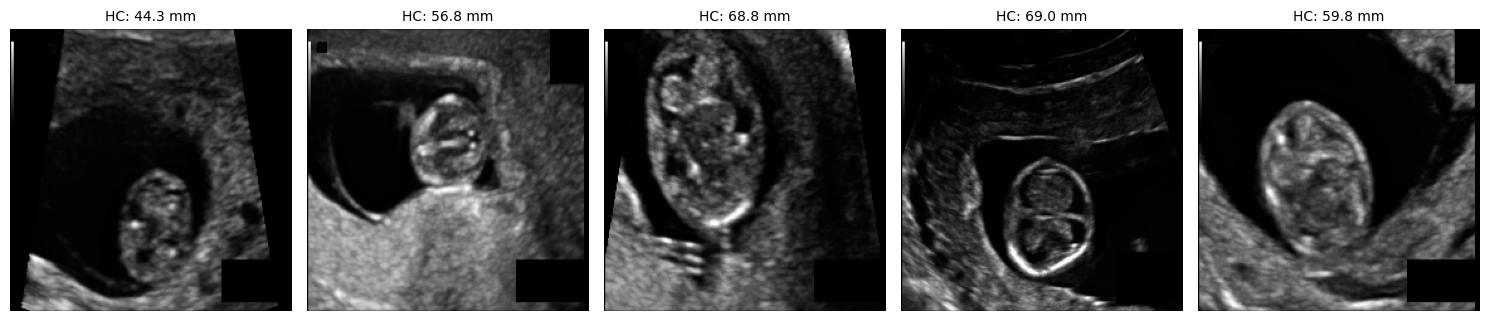

In [7]:
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    if y_train is not None:
        plt.title(f'HC: {y_train[i]:.1f} mm', fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


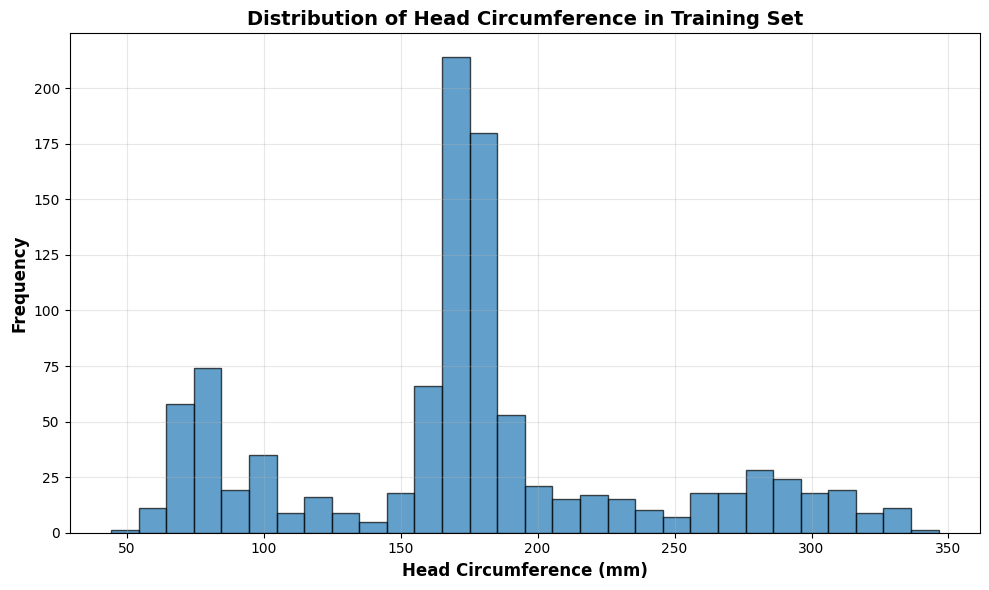

Mean HC: 174.38 mm
Std HC: 65.25 mm
Min HC: 44.30 mm
Max HC: 346.40 mm


In [8]:
if y_train is not None:
    plt.figure(figsize=(10, 6))
    plt.hist(y_train, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Head Circumference (mm)', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title('Distribution of Head Circumference in Training Set', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Mean HC: {np.mean(y_train):.2f} mm")
    print(f"Std HC: {np.std(y_train):.2f} mm")
    print(f"Min HC: {np.min(y_train):.2f} mm")
    print(f"Max HC: {np.max(y_train):.2f} mm")


In [9]:
if y_train is None:
    raise ValueError("Cannot train model without training labels. Please add the training_set_pixel_size_and_HC.csv file to your Kaggle dataset. You can download it from: https://zenodo.org/records/1327317")

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train_split)}")
print(f"Validation samples: {len(X_val)}")


Training samples: 799
Validation samples: 200


In [10]:
def create_model(input_shape=(224, 224, 1)):
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1)
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

model = create_model()
model.summary()


I0000 00:00:1769399601.195011      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,009 (2.48 MB)

 Trainable params: 651,009 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/50


I0000 00:00:1769399604.977907     122 service.cc:152] XLA service 0x799b84051810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769399604.977944     122 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769399605.430418     122 cuda_dnn.cc:529] Loaded cuDNN version 91002


 5/25 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 40889.4688 - mae: 188.4383

I0000 00:00:1769399610.697552     122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 300ms/step - loss: 27653.2227 - mae: 145.4414 - val_loss: 7243.0156 - val_mae: 71.8949 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 7361.1328 - mae: 66.6585 - val_loss: 4113.6670 - val_mae: 45.9319 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4911.4526 - mae: 54.1973 - val_loss: 4336.1660 - val_mae: 51.3905 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4721.6040 - mae: 53.5937 - val_loss: 4944.6958 - val_mae: 57.2889 - learning_rate: 0.0010
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 5174.2764 - mae: 56.2800 - val_loss: 3426.7771 - val_mae: 43.2846 - learning_rate: 0.0010
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4544.8486 - mae: 51.4169 - val_loss: 3421.9355 - val_mae: 43.5131 - learning_rate: 0.0010
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4243.3281 - mae: 49.8602 - val_loss: 4937.1592 - val_m

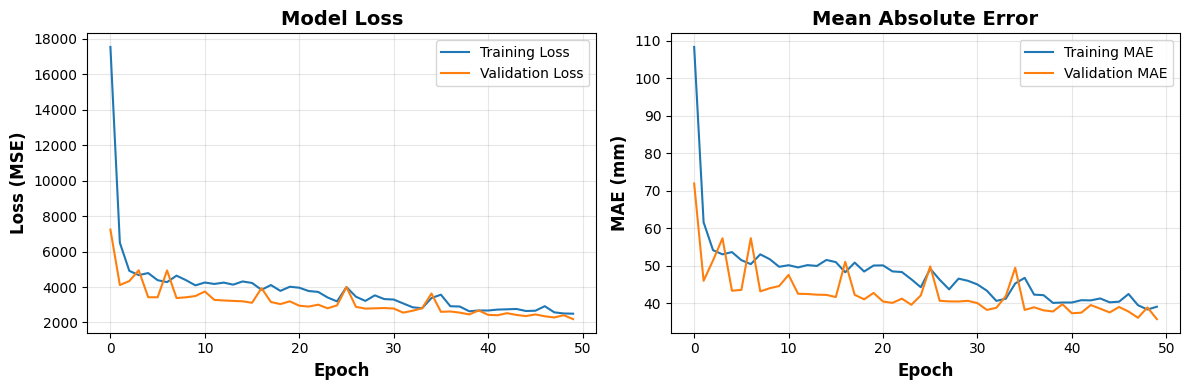

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('MAE (mm)', fontsize=12, fontweight='bold')
plt.title('Mean Absolute Error', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
y_pred_train = model.predict(X_train_split, verbose=0).flatten()
y_pred_val = model.predict(X_val, verbose=0).flatten()

train_mae = mean_absolute_error(y_train_split, y_pred_train)
val_mae = mean_absolute_error(y_val, y_pred_val)
train_rmse = np.sqrt(mean_squared_error(y_train_split, y_pred_train))
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
train_r2 = r2_score(y_train_split, y_pred_train)
val_r2 = r2_score(y_val, y_pred_val)

print("Training Metrics:")
print(f"  MAE: {train_mae:.2f} mm")
print(f"  RMSE: {train_rmse:.2f} mm")
print(f"  R²: {train_r2:.4f}")

print("\nValidation Metrics:")
print(f"  MAE: {val_mae:.2f} mm")
print(f"  RMSE: {val_rmse:.2f} mm")
print(f"  R²: {val_r2:.4f}")


Training Metrics:
  MAE: 35.14 mm
  RMSE: 45.58 mm
  R²: 0.5180

Validation Metrics:
  MAE: 35.71 mm
  RMSE: 46.81 mm
  R²: 0.4569


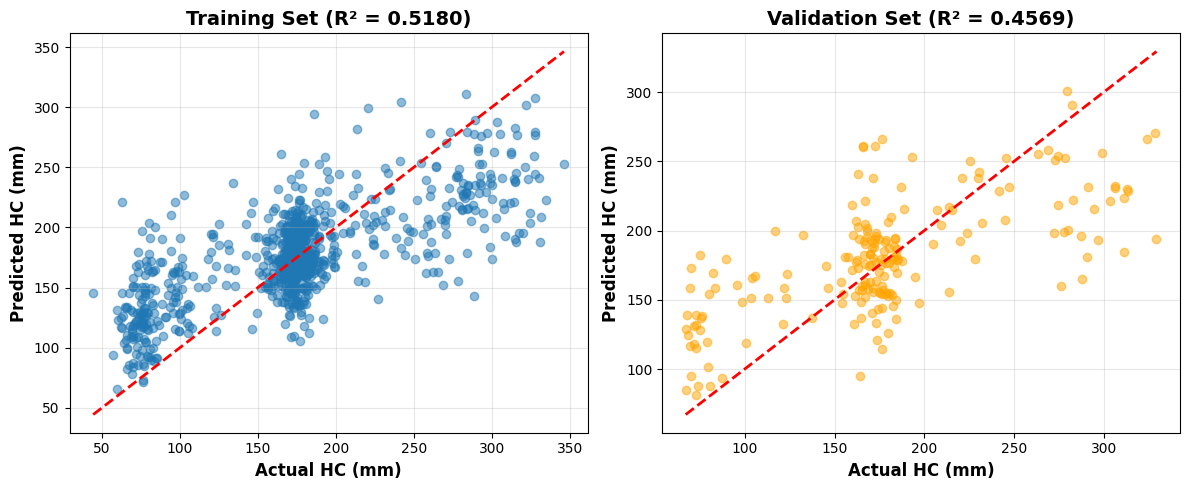

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train_split, y_pred_train, alpha=0.5)
plt.plot([y_train_split.min(), y_train_split.max()], 
         [y_train_split.min(), y_train_split.max()], 'r--', lw=2)
plt.xlabel('Actual HC (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted HC (mm)', fontsize=12, fontweight='bold')
plt.title(f'Training Set (R² = {train_r2:.4f})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_val, y_pred_val, alpha=0.5, color='orange')
plt.plot([y_val.min(), y_val.max()], 
         [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual HC (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted HC (mm)', fontsize=12, fontweight='bold')
plt.title(f'Validation Set (R² = {val_r2:.4f})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
y_pred_test = model.predict(X_test, verbose=0).flatten()

predictions_df = pd.DataFrame({
    'filename': test_images,
    'HeadCircumference': y_pred_test
})

predictions_df.to_csv(f'{OUTPUT_PATH}/predictions.csv', index=False)
print(f"Predictions saved to {OUTPUT_PATH}/predictions.csv")
print(f"\nFirst few predictions:")
print(predictions_df.head())


Predictions saved to /kaggle/working/predictions.csv

First few predictions:
     filename  HeadCircumference
0  000_HC.png         224.783981
1  001_HC.png         120.495049
2  002_HC.png         169.481033
3  003_HC.png         155.512466
4  004_HC.png         231.678391


In [16]:
model.save(f'{OUTPUT_PATH}/fetal_hc_model.keras')
print(f"Model saved to {OUTPUT_PATH}/fetal_hc_model.keras")


Model saved to /kaggle/working/fetal_hc_model.keras
